XAI para interpretabilidad de los modelos

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix


from captum.attr import (
    Saliency,
    IntegratedGradients,
    Occlusion,
    NoiseTunnel
)

import shap

c:\Users\naidl\miniconda3\envs\tfm_eeg\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
class EEGDataset(Dataset):
    def __init__(self, root_dir, sets=None):
        self.root_dir = root_dir

        if sets is None:
            sets = ['set_A','set_B','set_C','set_D','set_E']

        self.samples = []
        self.labels = []
        self.label_map = {s: i for i, s in enumerate(sets)}

        for set_name in sets:
            folder = os.path.join(root_dir, set_name)

            for file in sorted(os.listdir(folder)):
                if file.endswith('.txt'):
                    self.samples.append(os.path.join(folder, file))
                    self.labels.append(self.label_map[set_name])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path = self.samples[idx]

        signal = np.loadtxt(path)

        # convertir a tensor
        signal = torch.tensor(signal, dtype=torch.float32)

        # asegurar formato (canal=1, tiempo)
        signal = signal.unsqueeze(0)

        # normalización
        signal = (signal - signal.mean()) / (signal.std() + 1e-8)

        label = torch.tensor(self.labels[idx], dtype=torch.long)

        return signal, label

In [5]:
root_dir = '../data/raw'

dataset = EEGDataset(root_dir)

print("Total muestras:", len(dataset))

Total muestras: 400


In [6]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_ds, test_ds = random_split(dataset, [train_size, test_size])

In [7]:
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

In [8]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super(BaselineCNN, self).__init__()
        
        # --- BLOQUE 1: Extracción Temporal ---
        self.block1 = nn.Sequential(
            nn.Conv1d(
                in_channels=1,
                out_channels=16,
                kernel_size=5,
                stride=1,
                padding=2
            ),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        
        self.block2 = nn.Sequential(
            nn.Conv1d(
                in_channels=16,
                out_channels=32,
                kernel_size=5,
                stride=1,
                padding=2
            ),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        
        self.block3 = nn.Sequential(
            nn.Conv1d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.BatchNorm1d(64),
            nn.ReLU()
        )
        
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Linear(64, 1)

    def forward(self, x):
        
        """
        x shape: [Batch, Canales, 256]
        """
        batch_size, num_channels, seq_len = x.shape

        # Channel-independent
        #x = x.view(-1, 1, 256)        # [B*C, 1, 256]
        x = x.view(-1, 1, seq_len)     # [B*C, 1, seq_len]

        x = self.block1(x)            # [B*C, 16, 128]
        x = self.block2(x)            # [B*C, 32, 64]
        x = self.block3(x)            # [B*C, 64, 64]

        x = self.global_pool(x)       # [B*C, 64, 1]
        x = x.squeeze(-1)             # [B*C, 64]

        logits = self.classifier(x)   # [B*C, 1]
        #logits = logits.squeeze(-1)   # [B*C]

        # Voting por paciente
        logits = logits.view(batch_size, num_channels)
        logits = logits.mean(dim=1, keepdim=True)   # [Batch, 1]

        return logits

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BaselineCNN().to(device)
model.load_state_dict(torch.load("../models/baseline_cnn_bonn_noise.pth", map_location=device))
model.eval()

BaselineCNN(
  (block1): Sequential(
    (0): Conv1d(1, 16, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (global_pool): AdaptiveAvgPool1d(output_size=1)
  (classifier): Linear(in_features=64, out_features=1, bias=True)
)

In [10]:
def predict(model, loader):
    preds_all, labels_all = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)

            out = model(x)
            #preds = torch.argmax(out, dim=1).cpu().numpy()
            probs = torch.sigmoid(out)
            preds = (probs > 0.5).int().cpu().numpy()

            preds_all.extend(preds)
            labels_all.extend(y.numpy())

    return np.array(preds_all), np.array(labels_all)

c:\Users\naidl\miniconda3\envs\tfm_eeg\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\naidl\miniconda3\envs\tfm_eeg\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\naidl\miniconda3\envs\tfm_eeg\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

              precision    recall  f1-score   support

           0       0.28      1.00      0.44        17
           1       0.15      0.15      0.15        20
           3       0.00      0.00      0.00        23
           4       0.00      0.00      0.00        20

    accuracy                           0.25        80
   macro avg       0.11      0.29      0.15        80
weighted avg       0.10      0.25      0.13        80



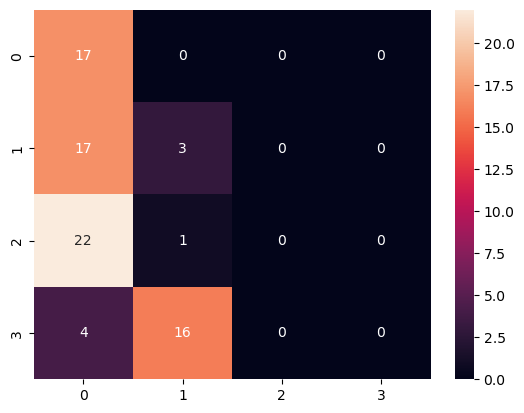

In [11]:
preds, labels = predict(model, test_loader)

print(classification_report(labels, preds))

cm = confusion_matrix(labels, preds)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

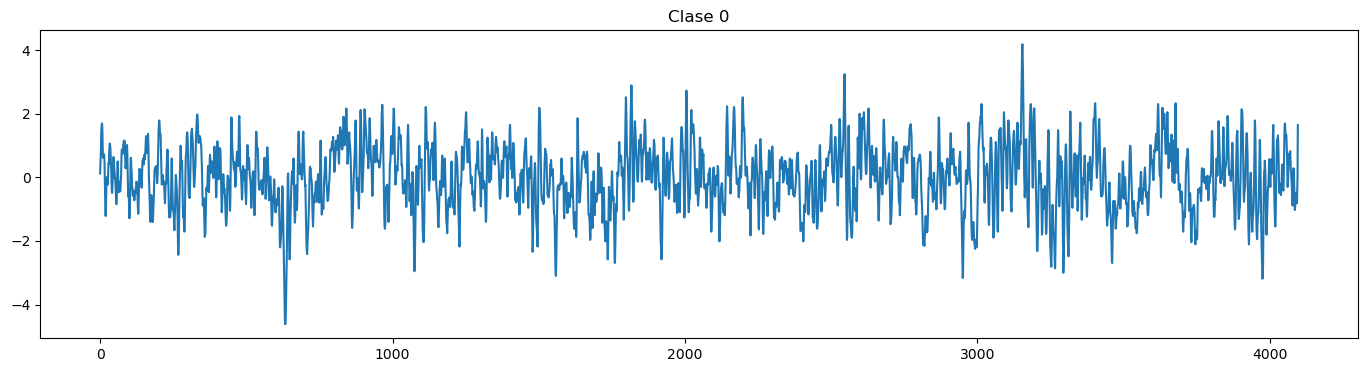

In [12]:
x, y = dataset[0]
x_input = x.unsqueeze(0).to(device)

plt.figure(figsize=(17, 4))
plt.plot(x.squeeze().numpy())
plt.title(f"Clase {y}")
plt.show()

In [13]:
# Obtenemos un lote de datos para las pruebas de XAI
dataiter = iter(test_loader)
signals, labels = next(dataiter)
signals = signals.to(device)

# Seleccionamos una muestra específica (por ejemplo, la primera del lote)
sample_idx = 0
input_signal = signals[sample_idx:sample_idx+1] # Conservar dimensión de batch [1, 1, seq_len]

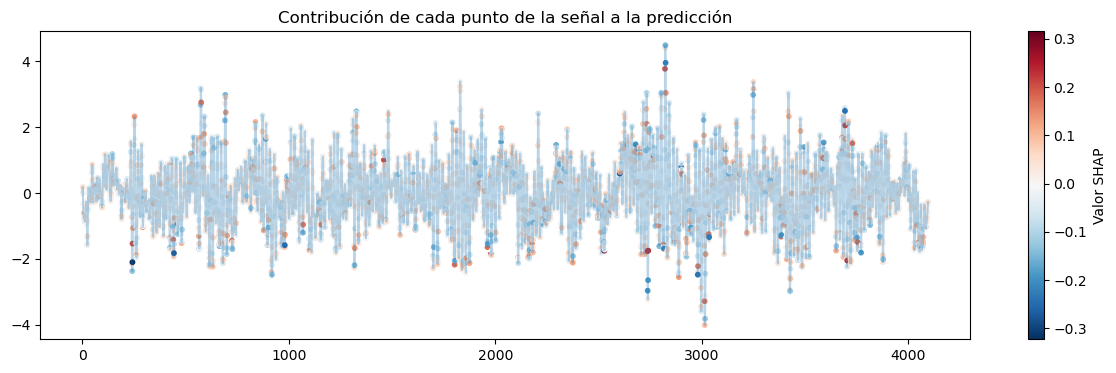

In [ ]:
import shap

# 1. Asegúrate de que el modelo esté en modo evaluación
model.eval()

# 2. Preparar datos de fondo (background) y prueba
# Tomamos un lote del loader
batch_signals, _ = next(iter(train_loader))
background = batch_signals[:10].to(device)
test_sample = signals[0:1].to(device)  # Una sola muestra para explicar

# 3. Inicializar GradientExplainer en lugar de DeepExplainer
# GradientExplainer tiene mejor compatibilidad con operaciones PyTorch modernas
explainer = shap.GradientExplainer(model, background)

# 4. Calcular valores SHAP
shap_values = explainer.shap_values(test_sample)

# 5. Visualización (SHAP devuelve una lista para cada salida, tomamos la primera)
shap_val = shap_values[0] if isinstance(shap_values, list) else shap_values
shap_val = np.asarray(shap_val)
if shap_val.ndim > 2:
    shap_val = shap_val.reshape(shap_val.shape[0], -1)
shap_val = shap_val.flatten()

signal_vals = test_sample.cpu().numpy().flatten()
plt.figure(figsize=(15, 4))
plt.plot(signal_vals, label='Señal EEG', alpha=0.3)
plt.scatter(range(len(shap_val)), signal_vals, c=shap_val, cmap='RdBu_r', s=10)
plt.colorbar(label='Valor SHAP')
plt.title("Contribución de cada punto de la señal a la predicción")
plt.show()

C:\Users\naidl\AppData\Local\Temp\ipykernel_8612\1099872578.py:39: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  cam = F.relu(torch.tensor(cam)).cpu().detach().numpy()


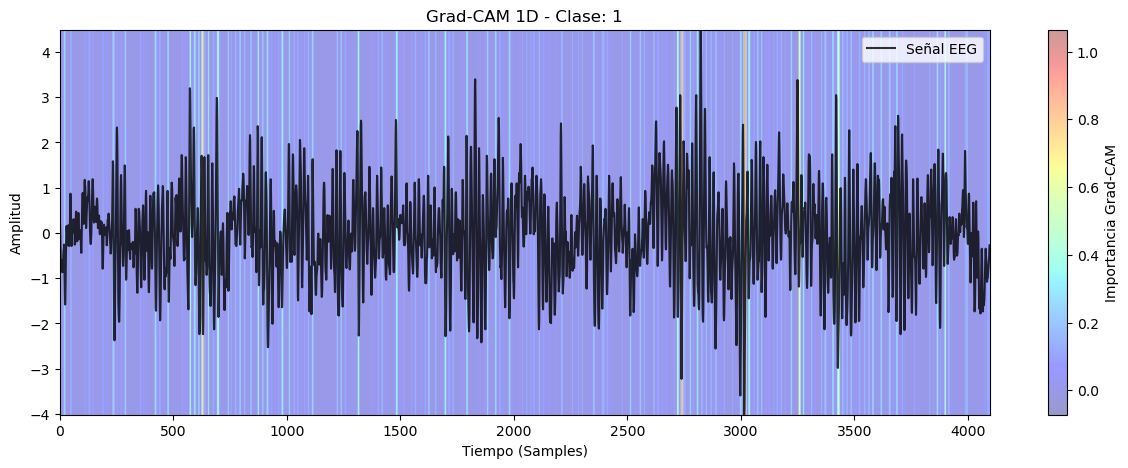

In [15]:
import torch.nn.functional as F

class GradCAM1D:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Registramos los hooks
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_tensor):
        # Asegurar modo eval pero con gradientes habilitados
        self.model.eval()
        
        # Paso hacia adelante
        output = self.model(input_tensor) # Forma: [1, 1]
        
        # Paso hacia atrás (backward)
        self.model.zero_grad()
        output.backward()

        # 1. Pesos: Promedio de los gradientes por canal (Global Average Pooling de gradientes)
        # self.gradients tiene forma: [Batch*Canales_EEG, Filtros, Longitud_Temporal]
        weights = torch.mean(self.gradients, dim=2, keepdim=True)

        # 2. Mapa de activación: Combinación lineal de activaciones y pesos
        cam = torch.sum(weights * self.activations, dim=1).squeeze()
        
        # 3. ReLU: Nos interesan solo las características que influyen positivamente
        cam = F.relu(torch.tensor(cam)).cpu().detach().numpy()
        
        # 4. Normalización
        if np.max(cam) != np.min(cam):
            cam = (cam - np.min(cam)) / (np.max(cam) - np.min(cam))
            
        return cam

# --- EJECUCIÓN ---

# 1. Seleccionamos la capa: Usaremos la última capa convolucional del Bloque 3
# En tu estructura es el primer elemento de la secuencia block3
target_layer = model.block3[0] 

# 2. Instanciamos y generamos
gcam = GradCAM1D(model, target_layer)

# Tomamos una muestra de test (asegúrate de que tenga forma [1, Num_Canales, Tiempo])
sample_signal, sample_label = next(iter(test_loader))
sample_input = sample_signal[0:1].to(device)

mask = gcam.generate(sample_input)

# 3. Visualización
from scipy.ndimage import zoom

plt.figure(figsize=(15, 5))
signal_plot = sample_input.cpu().squeeze().numpy()

# Ajustamos la máscara Grad-CAM al tamaño original de la señal (4097 puntos)
mask_resized = zoom(mask, signal_plot.shape[-1] / len(mask))

# Dibujamos la señal
plt.plot(signal_plot, color='black', alpha=0.8, label='Señal EEG')

# Superponemos el mapa de calor
plt.imshow(mask_resized[np.newaxis, :], aspect='auto', cmap='jet', alpha=0.4, 
           extent=[0, len(signal_plot), np.min(signal_plot), np.max(signal_plot)])

plt.colorbar(label='Importancia Grad-CAM')
plt.title(f'Grad-CAM 1D - Clase: {sample_label[0].item()}')
plt.xlabel('Tiempo (Samples)')
plt.ylabel('Amplitud')
plt.legend()
plt.show()

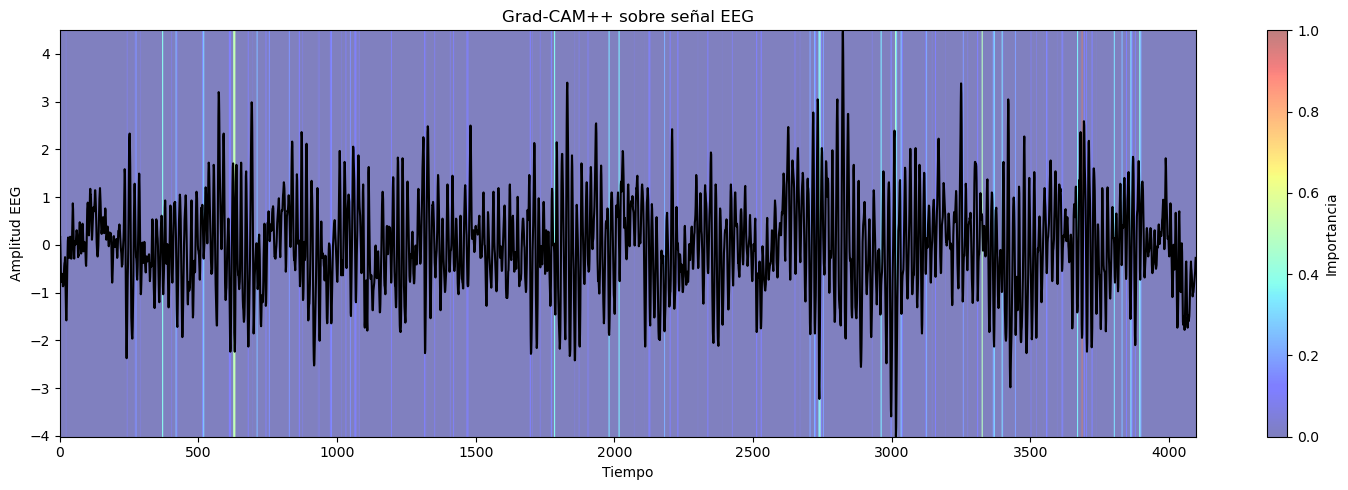

In [16]:
class GradCAMPlusPlus1D:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        # Hooks
        self.target_layer.register_forward_hook(self.forward_hook)
        self.target_layer.register_full_backward_hook(self.backward_hook)

    def forward_hook(self, module, input, output):
        self.activations = output

    def backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_cam(self, input_tensor, class_idx=None):

        self.model.eval()

        # Forward
        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        # Backward
        self.model.zero_grad()

        target = output[:, class_idx]
        target.backward(retain_graph=True)

        activations = self.activations.detach()
        gradients = self.gradients.detach()

        # ======================================
        # Grad-CAM++
        # ======================================

        gradients_power_2 = gradients ** 2
        gradients_power_3 = gradients ** 3

        sum_activations = torch.sum(activations, dim=2, keepdim=True)

        eps = 1e-8

        alpha_denom = (
            2 * gradients_power_2
            + sum_activations * gradients_power_3
        )

        alpha_denom = torch.where(
            alpha_denom != 0.0,
            alpha_denom,
            torch.ones_like(alpha_denom) * eps
        )

        alphas = gradients_power_2 / alpha_denom

        positive_gradients = F.relu(gradients)

        weights = torch.sum(alphas * positive_gradients, dim=2)

        weights = weights.unsqueeze(-1)

        cam = torch.sum(weights * activations, dim=1)

        # ReLU
        cam = F.relu(cam)

        # Normalización
        cam = cam - cam.min()

        if cam.max() != 0:
            cam = cam / cam.max()

        cam = cam.squeeze().cpu().numpy()

        return cam

# Última capa convolucional

target_layer = model.block3[0]

# Crear objeto Grad-CAM++
gradcam_pp = GradCAMPlusPlus1D(model, target_layer)

# Seleccionar una muestra
sample_signal = signals[0:1].to(device)

# Generar mapa
cam_pp = gradcam_pp.generate_cam(sample_signal)

signal_plot = sample_signal.squeeze().cpu().numpy()

plt.figure(figsize=(15, 5))

# Señal EEG
plt.plot(signal_plot, color='black', linewidth=1.5)

# Heatmap Grad-CAM++
plt.imshow(
    np.expand_dims(cam_pp, axis=0),
    aspect='auto',
    cmap='jet',
    alpha=0.5,
    extent=[0, len(signal_plot), signal_plot.min(), signal_plot.max()]
)

plt.colorbar(label='Importancia')

plt.title('Grad-CAM++ sobre señal EEG')
plt.xlabel('Tiempo')
plt.ylabel('Amplitud EEG')

plt.tight_layout()
plt.show()

C:\Users\naidl\AppData\Local\Temp\ipykernel_8612\1099872578.py:39: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  cam = F.relu(torch.tensor(cam)).cpu().detach().numpy()


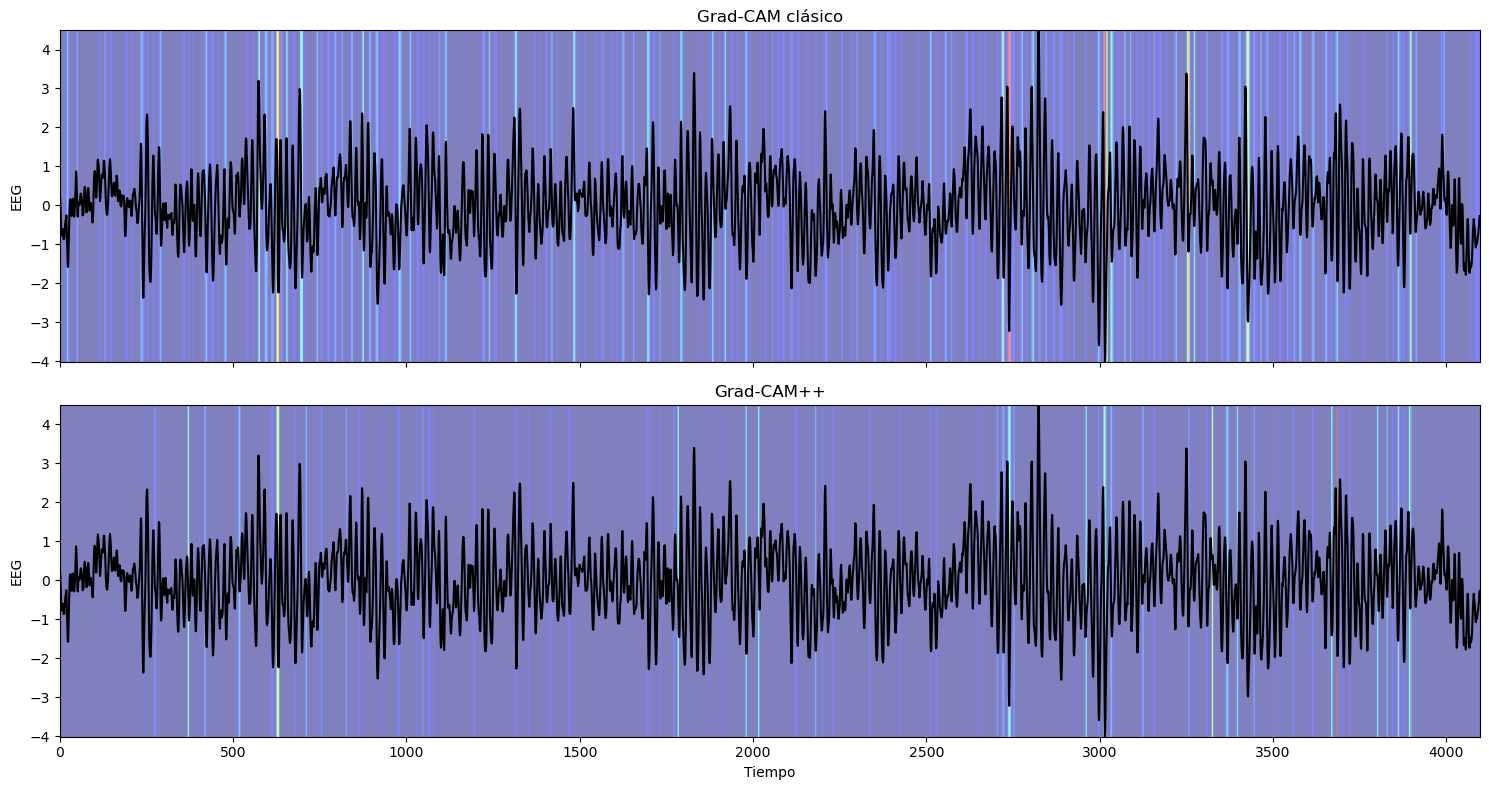

In [19]:
# Grad-CAM clásico
cam_classic = gcam.generate(sample_signal)

# Grad-CAM++
cam_pp = gradcam_pp.generate_cam(sample_signal)

signal_plot = sample_signal.squeeze().cpu().numpy()

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)


# =========================================
# Grad-CAM
# =========================================

axes[0].plot(signal_plot, color='black')

axes[0].imshow(
    np.expand_dims(cam_classic, axis=0),
    aspect='auto',
    cmap='jet',
    alpha=0.5,
    extent=[0, len(signal_plot), signal_plot.min(), signal_plot.max()]
)

axes[0].set_title('Grad-CAM clásico')
axes[0].set_ylabel('EEG')


# =========================================
# Grad-CAM++
# =========================================

axes[1].plot(signal_plot, color='black')

axes[1].imshow(
    np.expand_dims(cam_pp, axis=0),
    aspect='auto',
    cmap='jet',
    alpha=0.5,
    extent=[0, len(signal_plot), signal_plot.min(), signal_plot.max()]
)

axes[1].set_title('Grad-CAM++')
axes[1].set_xlabel('Tiempo')
axes[1].set_ylabel('EEG')

plt.tight_layout()
plt.show()